In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
from sklearn.metrics import confusion_matrix, classification_report , accuracy_score

## Reading Data And Pre-Processing 

In [2]:
import zipfile
import os

base_path = "Dataset"

def read_from_zip(filename):
    zip_path = os.path.join(base_path, f"{filename}.csv.zip")
    with zipfile.ZipFile(zip_path) as z:
        csv_name_inside = f"{filename}.csv"        
        return pd.read_csv(z.open(csv_name_inside))

train = read_from_zip("train")
test  = read_from_zip("test")
event_type = read_from_zip("event_type")
log_feature = read_from_zip("log_feature")
resource_type = read_from_zip("resource_type")
severity_type = read_from_zip("severity_type")
sample_sub  = read_from_zip("sample_submission")

In [3]:
print("All files loaded successfully!")
print(f"train: {train.shape}")
print(f"test: {test.shape}")
print(f"event_type: {event_type.shape}")
print(f"log_feature: {log_feature.shape}")
print(f"resource_type: {resource_type.shape}")
print(f"severity_type: {severity_type.shape}")

All files loaded successfully!
train: (7381, 3)
test: (11171, 2)
event_type: (31170, 2)
log_feature: (58671, 3)
resource_type: (21076, 2)
severity_type: (18552, 2)


In [4]:
train.head()

,id,location,fault_severity
0,14121,location 118,1
1,9320,location 91,0
2,14394,location 152,1
3,8218,location 931,1
4,14804,location 120,0


**We Need to get all information in one single table**

train.csv - the training set for fault severity 

test.csv - the test set for fault severity

sample_submission.csv - a sample submission file in the correct format

event_type.csv - event type related to the main dataset

log_feature.csv - features extracted from log files

resource_type.csv - type of resource related to the main dataset

severity_type.csv -  severity type of a warning message coming from the log


**Files we need in training are : train , severity_type , resource_type , log_feature , and event_type**

In [5]:
train_1 = train.merge(severity_type, how = 'left', left_on='id', right_on='id')
train_2 = train_1.merge(resource_type, how = 'left', left_on='id', right_on='id')
train_3 = train_2.merge(log_feature, how = 'left', left_on='id', right_on='id')
train_4 = train_3.merge(event_type, how = 'left', left_on='id', right_on='id')

In [6]:
train_4.head()

,id,location,fault_severity,severity_type,resource_type,log_feature,volume,event_type
0,14121,location 118,1,severity_type 2,resource_type 2,feature 312,19,event_type 34
1,14121,location 118,1,severity_type 2,resource_type 2,feature 312,19,event_type 35
2,14121,location 118,1,severity_type 2,resource_type 2,feature 232,19,event_type 34
3,14121,location 118,1,severity_type 2,resource_type 2,feature 232,19,event_type 35
4,9320,location 91,0,severity_type 2,resource_type 2,feature 315,200,event_type 34


We see that first 4 rows are duplicated, let's remove all duplicates  

**NOTE** 

The same id appears multiple times (intentionally), because one network location can have:

multiple event types , 
multiple log features , 
multiple resource types , 

So when you merge everything on id, you get multiple rows with the exact same feature values → they look like duplicates, but they are not real duplicates because they originally came from different source rows.

In [7]:
train_4.shape

(61839, 8)

In [8]:
train_4 = train_4.drop_duplicates(subset='id', keep='first').reset_index(drop=True)

In [9]:
train_4.head()

,id,location,fault_severity,severity_type,resource_type,log_feature,volume,event_type
0,14121,location 118,1,severity_type 2,resource_type 2,feature 312,19,event_type 34
1,9320,location 91,0,severity_type 2,resource_type 2,feature 315,200,event_type 34
2,14394,location 152,1,severity_type 2,resource_type 2,feature 221,1,event_type 35
3,8218,location 931,1,severity_type 1,resource_type 8,feature 80,9,event_type 15
4,14804,location 120,0,severity_type 1,resource_type 2,feature 134,1,event_type 34


In [10]:
train_4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7381 entries, 0 to 7380
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              7381 non-null   int64 
 1   location        7381 non-null   object
 2   fault_severity  7381 non-null   int64 
 3   severity_type   7381 non-null   object
 4   resource_type   7381 non-null   object
 5   log_feature     7381 non-null   object
 6   volume          7381 non-null   int64 
 7   event_type      7381 non-null   object
dtypes: int64(3), object(5)
memory usage: 461.4+ KB


In [11]:
train_4.isnull().sum()

id                0
location          0
fault_severity    0
severity_type     0
resource_type     0
log_feature       0
volume            0
event_type        0
dtype: int64

In [12]:
cat_cols = [col for col in train_4.columns if train_4[col].dtype == 'object']

train_4[cat_cols] = train_4[cat_cols].astype('category')

In [13]:
train_4.dtypes

id                   int64
location          category
fault_severity       int64
severity_type     category
resource_type     category
log_feature       category
volume               int64
event_type        category
dtype: object

In [14]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    train_4[col] = le.fit_transform(train_4[col])  
    label_encoders[col] = le

## EDA

Count plot for fault severity

C:\Users\Ahmed _ Alaa\AppData\Local\Temp\ipykernel_19056\4177854460.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_4, y=col, palette="mako", order=train_4[col].value_counts().index)
C:\Users\Ahmed _ Alaa\AppData\Local\Temp\ipykernel_19056\4177854460.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_4, y=col, palette="mako", order=train_4[col].value_counts().index)
C:\Users\Ahmed _ Alaa\AppData\Local\Temp\ipykernel_19056\4177854460.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_4, y=col, pale

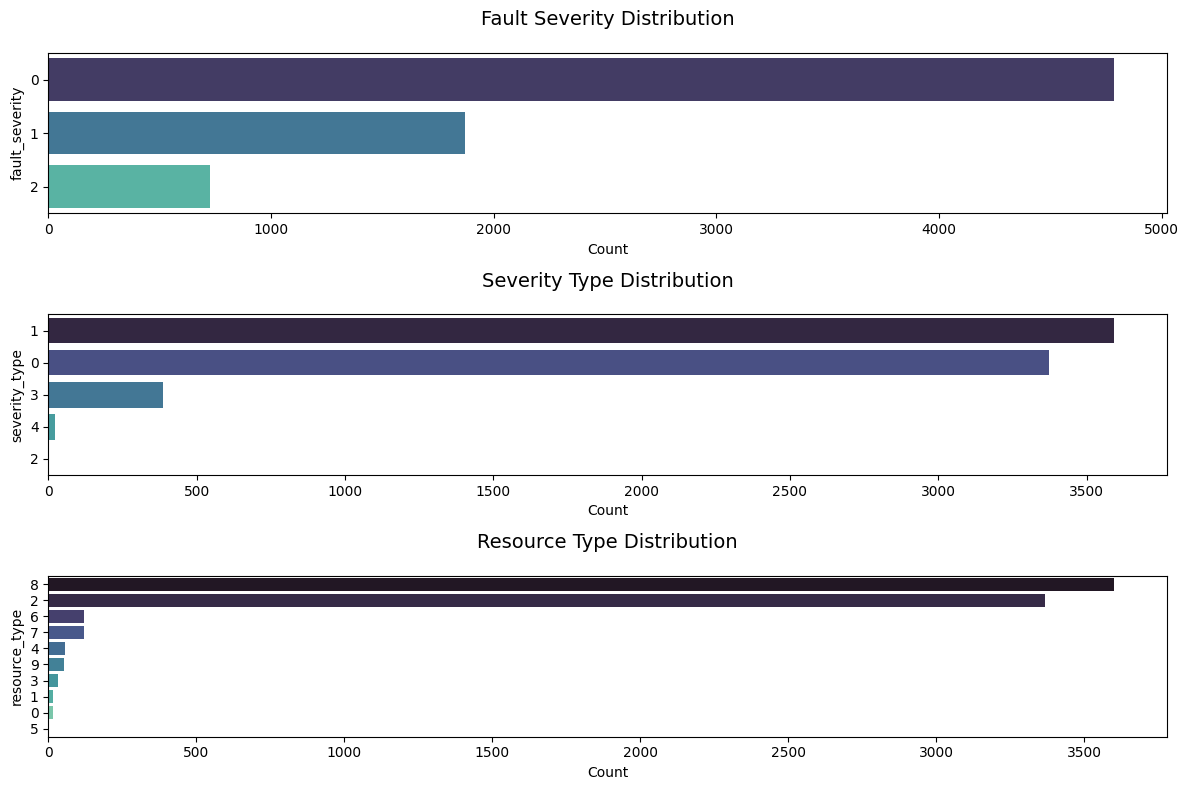

In [15]:
severity_cols = ['fault_severity', 'severity_type', 'resource_type']
plt.figure(figsize=(12, 8))

for i, col in enumerate(severity_cols):
    plt.subplot(3, 1, i+1)
    sns.countplot(data=train_4, y=col, palette="mako", order=train_4[col].value_counts().index)
    plt.title(f"{col.replace('_', ' ').title()} Distribution", fontsize=14, pad=20)
    plt.xlabel("Count")
    
plt.tight_layout()
plt.show()

**About** 

**Fault Severity** : 
Not very balanced data set as values with fault_severity ‘zero’ (indicating no fault) are very high as compared with others. So ML models might be biased towards fault severity value of ‘zero’.

**Severity Type** : 
Severity_type_1 and 2 are very high as compared with others.

**resource_type** :
Most of the resource types are either type_2 or type_8.

# Splitting Data

In [16]:
y = train_4['fault_severity']
X = train_4.drop(['id', 'fault_severity'], axis=1)

## Testing data processing

In [17]:
test.head()

,id,location
0,11066,location 481
1,18000,location 962
2,16964,location 491
3,4795,location 532
4,3392,location 600


In [18]:
test.shape

(11171, 2)

In [19]:
test_1 = test.merge(severity_type, how = 'left', left_on='id', right_on='id')
test_2 = test_1.merge(resource_type, how = 'left', left_on='id', right_on='id')
test_3 = test_2.merge(log_feature, how = 'left', left_on='id', right_on='id')
test_4 = test_3.merge(event_type, how = 'left', left_on='id', right_on='id')

In [20]:
test_categorical_cols = test_4.select_dtypes(include='category').columns

In [21]:
test_label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    test_4[col] = le.fit_transform(test_4[col])  
    test_label_encoders[col] = le

In [22]:
test_4.drop(['id'],axis=1,inplace=True)

# RandomForestClassifier

In [23]:
X.columns

Index(['location', 'severity_type', 'resource_type', 'log_feature', 'volume',
       'event_type'],
      dtype='object')

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier()
rf.fit(X,y)
rf_pred=rf.predict(test_4)
accuracy_score(pd.DataFrame(rf.predict(X)),y)

0.9697872916948923

## SVC

In [25]:
from sklearn.svm import SVC

svc_ml=SVC()
svc_ml.fit(X,y)
svc_ml.predict(test_4)
accuracy_score(pd.DataFrame(svc_ml.predict(X)),y)

0.6481506570925348

## KNN

In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier()
knn.fit(X,y)
knn.predict(test_4)
accuracy_score(pd.DataFrame(knn.predict(X)),y)

0.7591112315404417

In [ ]:
import joblib

joblib.dump(rf, "models/rf_model.pkl")
joblib.dump(svc_ml, "models/svm_model.pkl")
joblib.dump(knn, "models/knn_model.pkl")
joblib.dump(label_encoders, "models/label_encoders.pkl")

['label_encoders.pkl']